# **Práctica de Calidad de Datos y Minería en Python - Parte Calidad de Datos**
## **Integrantes**
- Alfonso Gabriel Jiménez Rivas
- Sebastián Soto Ángel

## **1. Calidad de Datos**

### **Importación de Librerías Básicas**

In [4]:
import pandas as pd # manipulacion dataframes
import numpy as np  # matrices y vectores
import matplotlib.pyplot as plt # gráfica

### **Carga de Datos**

In [5]:
# Se cargan los datos
data = pd.read_csv("arizona_sold_properties_2026.csv")
data.head()

,zip,type,year_built,listPrice,lastSoldPrice,list_to_sold_ratio,sqft,price_per_sqft,stories,beds,baths,baths_full,baths_full_calc,garage,sanitized_text
0,85018,single_family,2025.0,4498946.0,4300076.0,0.9558,5010.0,858.30,1.0,5.0,6.0,5.0,5.0,3.0,Located in the desirable Arcadia area of Phoen...
1,85377,single_family,2009.0,1799089.0,1750060.0,0.9727,4270.0,409.85,1.0,5.0,5.0,4.0,4.0,3.0,"The home is hard-wired for streaming, with Eth..."
2,85037,single_family,1973.0,335083.0,328911.0,0.9816,1360.0,241.85,1.0,4.0,2.0,1.0,1.0,2.0,Sharp 4 bedroom 1.75 bathroom two car garage l...
3,85037,single_family,1973.0,429828.0,434291.0,1.0104,1510.0,287.61,1.0,4.0,2.0,2.0,2.0,2.0,The remodeled kitchen features warm wood cabin...
4,85037,single_family,1973.0,299927.0,294935.0,0.9834,1240.0,237.85,1.0,3.0,2.0,2.0,2.0,2.0,"Phoenix, Arizona, home has 3 bedrooms, 2 bathr..."


In [6]:
# Información del dataset
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9954 entries, 0 to 9953
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   zip                 9954 non-null   int64  
 1   type                9953 non-null   object 
 2   year_built          9917 non-null   float64
 3   listPrice           8881 non-null   float64
 4   lastSoldPrice       9954 non-null   float64
 5   list_to_sold_ratio  8879 non-null   float64
 6   sqft                9922 non-null   float64
 7   price_per_sqft      9922 non-null   float64
 8   stories             9314 non-null   float64
 9   beds                8903 non-null   float64
 10  baths               9946 non-null   float64
 11  baths_full          8857 non-null   float64
 12  baths_full_calc     8892 non-null   float64
 13  garage              8654 non-null   float64
 14  sanitized_text      8784 non-null   object 
dtypes: float64(12), int64(1), object(2)
memory usage: 1.1+ 

### **A. Perfilado de los Datos con YData Profiling**

In [7]:
!pip install ydata-profiling

from ydata_profiling import ProfileReport

profile_data=ProfileReport(data, minimal=True) # minimal=True
profile_data

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.8/400.8 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 19.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 55.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.7/679.7 kB 28.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 5.3 MB/s eta 0:00:00


/tmp/ipykernel_6430/340952533.py:3: DeprecationWarning: 
    `import ydata_profiling` is deprecated and will not receive more updates. 
    Please install fg-data-profiling via `pip install fg-data-profiling` and use `import data_profiling` instead.
    
  from ydata_profiling import ProfileReport


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 15/15 [00:01<00:00, 13.39it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

In [8]:
# Guardamos en HTML el perfilado de datos
profile_data.to_file(output_file="output.html")

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

### **Dimensiones de la Calidad de Datos**

**Completitud:** ¿Está toda la información disponible? ¿Hay datos faltantes o ausentes?

**Exactitud:**¿La información es correcta y libre de error?

**Conformidad:** ¿Los valores de los datos están conformes con los formatos esperados? Ejemplo: Una fecha en formato AAAA/MM/DD cuando debería ser DD/MM/AAAA.

**Oportunidad:** ¿La información llega cuando se necesita?

**Duplicidad:** ¿Existen múltiples instancias, innecesarias de los mismos objetos de datos en el conjunto de datos?

**Integridad:** ¿Faltan datos relacionados importantes? ¿Es clara la conectividad y las relaciones con otros datos?

### **B. Diagnóstico de las Dimensiones según el Perfilado:**
* **Completitud:** Ocho de las quince variables que presenta el dataset contienen valores faltantes, cada una de estas con entre el 6-14% de datos nulos. Esto es de esperarse, dado que el autor del dataset menciona que los outliers fueron declarados como nulos para garantizar integridad analítica.
* **Exactitud:** No hay indicios para sospechar que los valores no son exactos. El autor menciona un proceso de recolección cuidadosa de datos en el artículo de publicación del conjunto de datos.
* **Conformidad:** Sólo se puede hacer la precisión de que los datos de la variable "year_built" sería más útil si fuera presentada como años desde que la casa fue construida, logrando mayor claridad en la escala de esta variable numérica.
* **Oportunidad:** Aunque ambigüo en la descripción del dataset, se presume que el dataset describe propiedades vendidas en 2026. Esto hace que sea información oportuna, especialmente para extraer métricas como el 'heat' del mercado o información general del mercado del real-estate en Arizona.
* **Duplicidad:** No cuenta con datos duplicados.
* **Integridad:** La base de datos se encuentra enteramente íntegra.

### **C. Limpieza de Datos**

#### **Remover Variables Irrelevantes**
- **type:** valor constante "single_family", no aporta información predictiva
- **list_to_sold_ratio:** variable derivada de listPrice y lastSoldPrice, redundante
- **price_per_sqft:** variable derivada de lastSoldPrice y sqft, redundante. Además genera data leakage con el target
- **baths_full_calc:** duplicado calculado de baths_full, no agrega información nueva
- **sanitized_text:** texto libre sin uso en este análisis, se descarta por no aplicar NLP

In [9]:
data.drop(columns=['type','list_to_sold_ratio','price_per_sqft','baths_full_calc','sanitized_text'], inplace=True)

In [10]:
data.head()

,zip,year_built,listPrice,lastSoldPrice,sqft,stories,beds,baths,baths_full,garage
0,85018,2025.0,4498946.0,4300076.0,5010.0,1.0,5.0,6.0,5.0,3.0
1,85377,2009.0,1799089.0,1750060.0,4270.0,1.0,5.0,5.0,4.0,3.0
2,85037,1973.0,335083.0,328911.0,1360.0,1.0,4.0,2.0,1.0,2.0
3,85037,1973.0,429828.0,434291.0,1510.0,1.0,4.0,2.0,2.0,2.0
4,85037,1973.0,299927.0,294935.0,1240.0,1.0,3.0,2.0,2.0,2.0


- Se analiza la distribución de frecuencias por ZIP para evaluar si el encoding es adecuado. Se observa que la mitad de los ZIPs tienen 25 o menos ventas y el 25% tiene 8 o menos, lo que indica que muchos ZIPs tienen pocas observaciones. Por esto se usa Target Encoding
con smoothing en lugar de un encoding simple.

In [11]:
data['zip'].value_counts().describe()

,count
count,292.000000
mean,34.089041
std,34.171373
min,1.000000
25%,8.000000
50%,25.500000
75%,48.000000
max,193.000000


- Se reemplaza el ZIP por el promedio de lastSoldPrice por zona geográfica. Esto permite capturar la información geográfica de forma numérica sin generar 292 columnas dummy (One-Hot Encoding). Se usa smoothing=10 para suavizar ZIPs con pocas observaciones, jalando su valor hacia el promedio global y evitando estimaciones poco confiables.

In [12]:
!pip install category_encoders
from category_encoders import TargetEncoder

# Target encoding del ZIP
encoder = TargetEncoder(smoothing=10)
data['zip_encoded'] = encoder.fit_transform(data['zip'].astype('category'), data['lastSoldPrice'])
data.drop(columns=['zip'], inplace=True)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 1.1 MB/s eta 0:00:00


- Se guarda el encoder para su uso posterior en el despliegue de la interfaz gráfica, ya que contiene el mapeo de cada ZIP code a su valor numérico correspondiente, permitiendo convertir automáticamente el ZIP ingresado por el usuario sin que este tenga que conocer el valor codificado.


In [13]:
# Guardar encoder para la interfaz
import pickle
with open('zip_encoder.pkl', 'wb') as f:
    pickle.dump(encoder, f)

### **Visualización Nuevos Tipos de Datos y Columnas**

In [14]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9954 entries, 0 to 9953
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   year_built     9917 non-null   float64
 1   listPrice      8881 non-null   float64
 2   lastSoldPrice  9954 non-null   float64
 3   sqft           9922 non-null   float64
 4   stories        9314 non-null   float64
 5   beds           8903 non-null   float64
 6   baths          9946 non-null   float64
 7   baths_full     8857 non-null   float64
 8   garage         8654 non-null   float64
 9   zip_encoded    9954 non-null   float64
dtypes: float64(10)
memory usage: 777.8 KB


In [15]:
data.head()

,year_built,listPrice,lastSoldPrice,sqft,stories,beds,baths,baths_full,garage,zip_encoded
0,2025.0,4498946.0,4300076.0,5010.0,1.0,5.0,6.0,5.0,3.0,2.463056e+06
1,2009.0,1799089.0,1750060.0,4270.0,1.0,5.0,5.0,4.0,3.0,1.044503e+06
2,1973.0,335083.0,328911.0,1360.0,1.0,4.0,2.0,1.0,2.0,3.830214e+05
3,1973.0,429828.0,434291.0,1510.0,1.0,4.0,2.0,2.0,2.0,3.830214e+05
4,1973.0,299927.0,294935.0,1240.0,1.0,3.0,2.0,2.0,2.0,3.830214e+05


### **Limpieza de Datos Nulos: Imputación**
Todas las columnas tenían menos del 15% de nulos. Al ser todas variables numéricas,
se evalúa el sesgo (skew) de cada una para determinar el método de imputación adecuado,
siguiendo esta regla:

- **Skew entre -0.5 y 0.5** → distribución simétrica → imputar con **media**
- **Skew fuera de ese rango** → distribución sesgada con outliers → imputar con **mediana**

Dado que todas las variables presentaron skew fuera del rango simétrico,
se imputan **todas con la mediana**, que es más robusta ante valores extremos.

In [16]:
# lasSoldPrice es nuestra variable objetivo, no se imputa
data.skew().sort_values(ascending=False)


,0
lastSoldPrice,33.038835
listPrice,9.339385
zip_encoded,5.588949
garage,4.167275
sqft,3.282726
baths_full,2.525146
stories,1.702040
baths,0.589850
beds,0.531739
year_built,-0.872514


In [17]:
# Limpieza de datos nulos: Imputación por la media
from sklearn.impute import SimpleImputer

# Imputacion de variables numéricas: media, mediana
var_numericas = ['stories','beds','baths_full','garage','baths','sqft','year_built']
ImpNumeros = SimpleImputer(missing_values=np.nan, strategy='mean')
data[var_numericas] = ImpNumeros.fit_transform(data[var_numericas])

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9954 entries, 0 to 9953
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   year_built     9954 non-null   float64
 1   listPrice      8881 non-null   float64
 2   lastSoldPrice  9954 non-null   float64
 3   sqft           9954 non-null   float64
 4   stories        9954 non-null   float64
 5   beds           9954 non-null   float64
 6   baths          9954 non-null   float64
 7   baths_full     9954 non-null   float64
 8   garage         9954 non-null   float64
 9   zip_encoded    9954 non-null   float64
dtypes: float64(10)
memory usage: 777.8 KB


### **Correlaciones para Redundancias**

- **Revisión de correlaciones para redundancias (|r| > 0.8):** Por prudencia, se elimina la variable listPrice, la cual conserva una correlación muy cercana a la variable objetivo lastSoldPrice, que siempre depende de la anteriormente mencionada.

<Axes: >

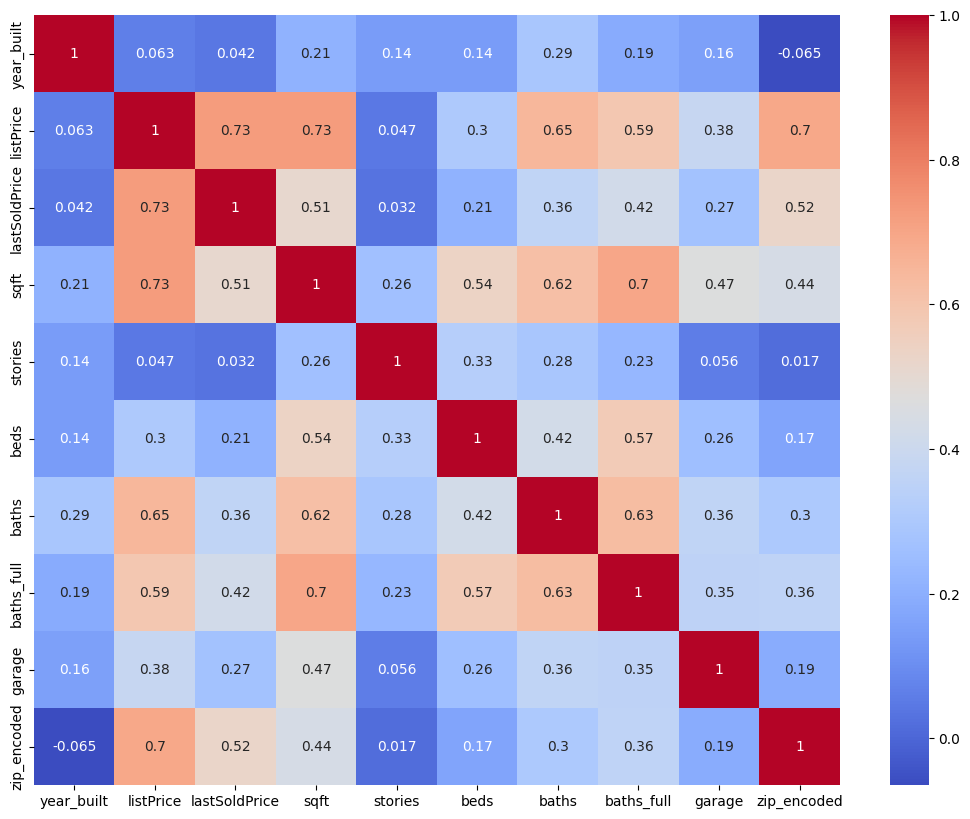

In [18]:
import seaborn as sns

# Calcular la matriz de correlación
corr_matrix = data.corr()

plt.figure(figsize=(13,10))
sns.heatmap(corr_matrix,annot=True, cmap='coolwarm')

In [19]:
data.drop(columns=['listPrice'], inplace=True)

### **Correlaciones para Irrelevancias con la Variable Objetivo**
- Se buscan correlaciones muy bajas (|r| < 0.05) que indiquen variables poco relevantes → última fila

In [20]:
#Correlaciones con la variable de objetivo
cor_variable_obj=corr_matrix.loc['lastSoldPrice']
cor_variable_obj

,lastSoldPrice
year_built,0.041935
listPrice,0.726412
lastSoldPrice,1.000000
sqft,0.511823
stories,0.032261
beds,0.210761
baths,0.363394
baths_full,0.421299
garage,0.269332
zip_encoded,0.522397


- Se remueven las dos columnas con correlaciones < 0.05 con la variable objetivo **lastSoldPrice**

In [21]:
data.drop(['stories', 'year_built'], axis=1)

,lastSoldPrice,sqft,beds,baths,baths_full,garage,zip_encoded
0,4300076.0,5010.0,5.000000,6.0,5.000000,3.000000,2.463056e+06
1,1750060.0,4270.0,5.000000,5.0,4.000000,3.000000,1.044503e+06
2,328911.0,1360.0,4.000000,2.0,1.000000,2.000000,3.830214e+05
3,434291.0,1510.0,4.000000,2.0,2.000000,2.000000,3.830214e+05
4,294935.0,1240.0,3.000000,2.0,2.000000,2.000000,3.830214e+05
...,...,...,...,...,...,...,...
9949,304900.0,1980.0,2.000000,2.0,2.000000,2.000000,3.598641e+05
9950,999933.0,3720.0,3.372571,0.0,2.292311,3.000000,2.200199e+06
9951,410091.0,2040.0,3.000000,2.0,2.000000,3.000000,3.598641e+05
9952,590092.0,1660.0,4.000000,2.0,2.000000,2.370349,1.536018e+06


### **Se Guardan los Datos Limpios**

In [22]:
data.to_csv('./datos_limpios_arizona.csv', index=False)